In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings, os
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    accuracy_score, f1_score
)
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.sklearn

plt.rcParams['figure.figsize'] = (10, 5)
print('All libraries imported!')

All libraries imported!


In [5]:
X_train = pd.read_csv('data/processed/X_train.csv')
X_test  = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('data/processed/y_test.csv').squeeze()

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Attack rate — train: {y_train.mean():.2%}  |  test: {y_test.mean():.2%}')
print(f'\nFeatures used: {X_train.columns.tolist()}')

X_train: (869762, 20)  |  X_test: (217441, 20)
Attack rate — train: 2.04%  |  test: 2.04%

Features used: ['sttl', 'ct_state_ttl', 'dttl', 'tcprtt', 'ackdat', 'synack', 'sload', 'short_flow', 'high_src_load', 'byte_ratio', 'state_enc', 'ct_dst_sport_ltm', 'pkt_ratio', 'dmeansz', 'ct_src_dport_ltm', 'dload', 'swin', 'dwin', 'sjit', 'total_jit']


In [6]:
print('Before SMOTE:')
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(pd.Series(y_res).value_counts())
print(f'\n Resampled training set: {X_res.shape}')

Before SMOTE:
binary_label
0    851990
1     17772
Name: count, dtype: int64

After SMOTE:
binary_label
0    851990
1    851990
Name: count, dtype: int64

 Resampled training set: (1703980, 20)


In [7]:
print('Training XGBoost on UNSW-NB15 features...')

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_res, y_res)
print('XGBoost training done!')

Training XGBoost on UNSW-NB15 features...
XGBoost training done!


In [8]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred_xgb)
f1  = f1_score(y_test, y_pred_xgb)
auc = roc_auc_score(y_test, y_prob_xgb)

print('=' * 45)
print(f'  Accuracy : {acc:.4f}')
print(f'  F1 Score : {f1:.4f}')
print(f'  AUC-ROC  : {auc:.4f}')
print('=' * 45)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Attack']))

  Accuracy : 0.9967
  F1 Score : 0.9242
  AUC-ROC  : 0.9998

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    212998
      Attack       0.86      1.00      0.92      4443

    accuracy                           1.00    217441
   macro avg       0.93      1.00      0.96    217441
weighted avg       1.00      1.00      1.00    217441



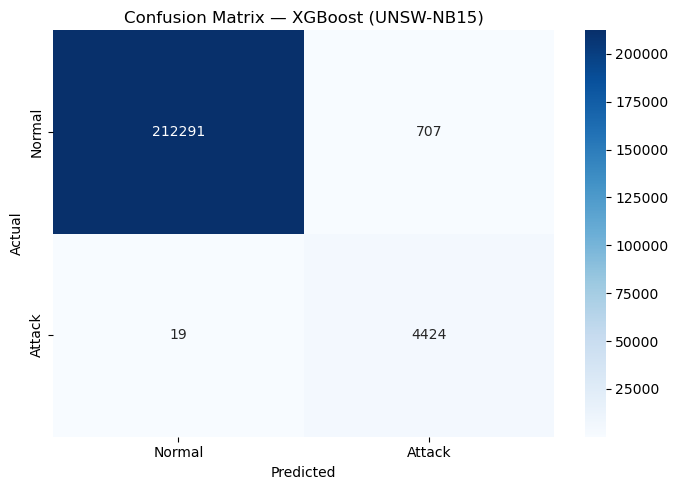

In [9]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix — XGBoost (UNSW-NB15)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

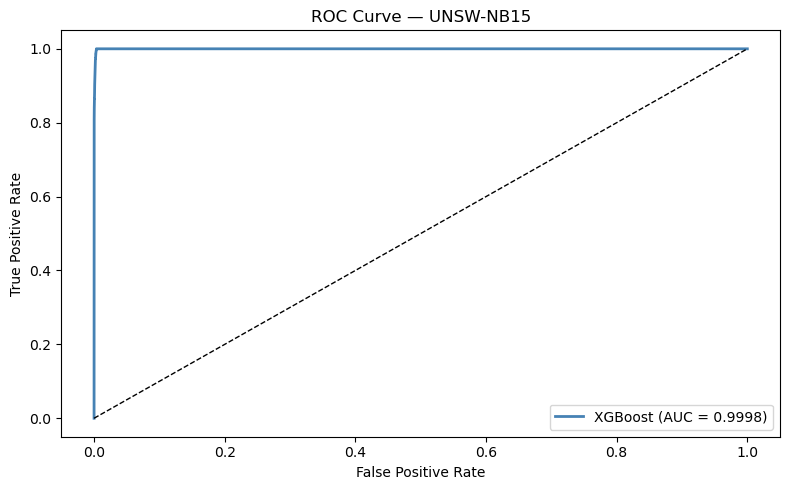

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'XGBoost (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — UNSW-NB15')
plt.legend()
plt.tight_layout()
plt.show()

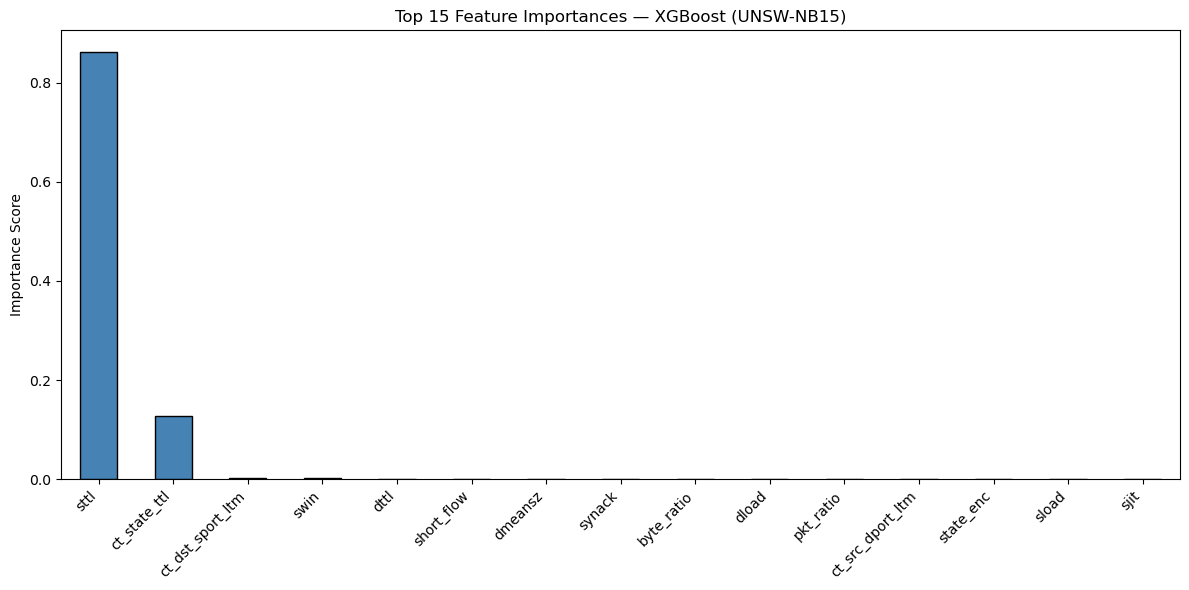

In [11]:
feat_imp = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
feat_imp.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances — XGBoost (UNSW-NB15)')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
print('Training Random Forest...')

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_res, y_res)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(f'Random Forest — Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}  '
      f'F1: {f1_score(y_test, y_pred_rf):.4f}  '
      f'AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')
print(' Random Forest done!')

Training Random Forest...
Random Forest — Accuracy: 0.9964  F1: 0.9193  AUC: 0.9997
 Random Forest done!


In [16]:
print('Training Isolation Forest on normal traffic only...')

iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,   # ~5% contamination matches UNSW-NB15 ratio
    random_state=42,
    n_jobs=-1
)

# Train only on normal (label=0) traffic
X_normal = X_train[y_train == 0]
iso.fit(X_normal)

# Evaluate: -1 = anomaly (attack), 1 = normal
iso_preds  = iso.predict(X_test)
iso_labels = (iso_preds == -1).astype(int)   # convert to 0/1

iso_f1  = f1_score(y_test, iso_labels)
iso_acc = accuracy_score(y_test, iso_labels)
print(f'Isolation Forest — Accuracy: {iso_acc:.4f}  F1: {iso_f1:.4f}')
print(' Isolation Forest done!')

Training Isolation Forest on normal traffic only...
Isolation Forest — Accuracy: 0.9510  F1: 0.4548
 Isolation Forest done!


In [17]:
comparison = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest', 'Isolation Forest (unsupervised)'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_xgb), 4),
        round(accuracy_score(y_test, y_pred_rf),  4),
        round(iso_acc, 4)
    ],
    'F1 Score': [
        round(f1_score(y_test, y_pred_xgb), 4),
        round(f1_score(y_test, y_pred_rf),  4),
        round(iso_f1, 4)
    ],
    'AUC-ROC': [
        round(roc_auc_score(y_test, y_prob_xgb), 4),
        round(roc_auc_score(y_test, y_prob_rf),  4),
        'N/A'
    ]
})

print('\n Model Comparison — UNSW-NB15:')
display(comparison)


 Model Comparison — UNSW-NB15:


,Model,Accuracy,F1 Score,AUC-ROC
0,XGBoost,0.9967,0.9242,0.9998
1,Random Forest,0.9964,0.9193,0.9997
2,Isolation Forest (unsupervised),0.9510,0.4548,N/A


In [18]:
mlflow.set_experiment('smart-api-protection-unsw-nb15')

with mlflow.start_run(run_name='xgboost_unswnb15_run'):
    # Log parameters
    mlflow.log_param('dataset',       'UNSW-NB15')
    mlflow.log_param('model',         'XGBoost')
    mlflow.log_param('n_estimators',  200)
    mlflow.log_param('max_depth',     6)
    mlflow.log_param('learning_rate', 0.1)
    mlflow.log_param('smote',         True)

    # Log metrics
    mlflow.log_metric('accuracy', round(acc, 4))
    mlflow.log_metric('f1_score', round(f1,  4))
    mlflow.log_metric('auc_roc',  round(auc, 4))

    # Log model
    mlflow.sklearn.log_model(xgb, 'xgb_model')

print(' Logged to MLflow!')
print('Run: mlflow ui   then open http://localhost:5000')

2026/04/28 13:25:28 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/28 13:25:28 INFO mlflow.store.db.utils: Updating database tables
2026/04/28 13:25:29 INFO mlflow.tracking.fluent: Experiment with name 'smart-api-protection-unsw-nb15' does not exist. Creating a new experiment.
2026/04/28 13:25:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 13:25:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 Logged to MLflow!
Run: mlflow ui   then open http://localhost:5000


In [19]:
os.makedirs('models', exist_ok=True)

joblib.dump(xgb, 'models/classifier.pkl')
joblib.dump(rf,  'models/random_forest.pkl')
joblib.dump(iso, 'models/anomaly_detector.pkl')

print(' Models saved:')
print('  models/classifier.pkl        (XGBoost — main model, trained on UNSW-NB15)')
print('  models/random_forest.pkl     (backup)')
print('  models/anomaly_detector.pkl  (Isolation Forest — detects novel attacks)')

 Models saved:
  models/classifier.pkl        (XGBoost — main model, trained on UNSW-NB15)
  models/random_forest.pkl     (backup)
  models/anomaly_detector.pkl  (Isolation Forest — detects novel attacks)


In [20]:
# Load models back and do a quick test
clf     = joblib.load('models/classifier.pkl')
anomaly = joblib.load('models/anomaly_detector.pkl')

# Pick one test sample
sample = X_test.iloc[[0]]
actual = y_test.iloc[0]

threat_score = clf.predict_proba(sample)[0][1]
anomaly_flag = anomaly.predict(sample)[0]   # -1 = anomaly

if threat_score > 0.85 or anomaly_flag == -1:
    decision = 'BLOCK'
elif threat_score > 0.5:
    decision = 'FLAG'
else:
    decision = 'ALLOW'

print('--- Sample Prediction (UNSW-NB15) ---')
print(f'Actual label  : {"Attack" if actual == 1 else "Normal"}')
print(f'Threat score  : {threat_score:.4f}')
print(f'Anomaly flag  : {anomaly_flag == -1}')
print(f'Decision      : {decision}')

--- Sample Prediction (UNSW-NB15) ---
Actual label  : Normal
Threat score  : 0.0000
Anomaly flag  : False
Decision      : ALLOW
